# Overfitting, Underfitting, and Validation Curves

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

You have already met overfitting as a symptom: a model that scores much better on the data it trained on than on data it has never seen. In this notebook you will create that failure on purpose and watch it happen. We use a small synthetic dataset so you can see each model's behavior directly against the true pattern that generated the data.

You will fit polynomial models of increasing complexity and watch them go from too simple (<b>underfitting</b>) to just right to too complex (<b>overfitting</b>). Along the way you will build a <b>validation curve</b>, the standard tool for choosing model complexity, and finish with a first look at how <b>regularization</b> can fix an overfitting model without removing any features.

</div>

---
## Step 1: A Dataset You Can See

Real datasets never tell you the true relationship behind them. Synthetic datasets do, and that is exactly why they are good for building intuition: we generate the data from a known pattern, then judge each model by how well it recovers that pattern from noisy points.

Our scenario: fuel efficiency of a car as a function of driving speed. Efficiency is poor at very low speeds, peaks somewhere in the middle, and drops again at highway speeds. We generate 70 noisy measurements of that relationship.

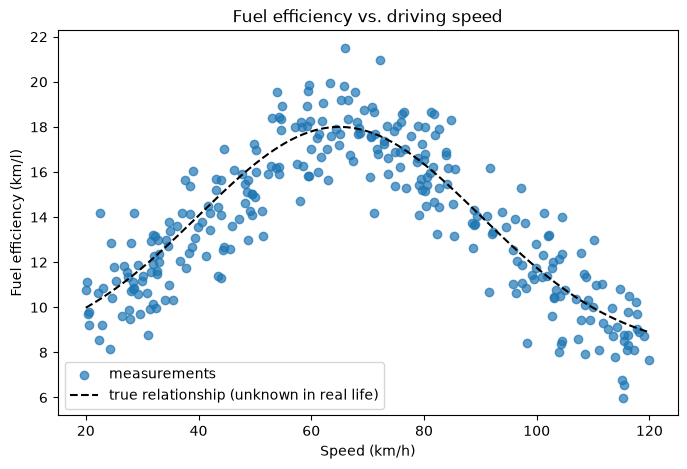

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

RANDOM_SEED = 23
np.random.seed(RANDOM_SEED)

n_samples = 300
noise_sd = 1.5

# Fuel efficiency (km per liter) as a function of driving speed (km/h).
# True relationship: efficiency peaks around 65 km/h and drops off on both sides.
speed = np.random.uniform(20, 120, n_samples)
true_efficiency = 8 + 10 * np.exp(-0.5 * ((speed - 65) / 25) ** 2)
efficiency = true_efficiency + np.random.normal(0, noise_sd, n_samples)

grid_speed = np.linspace(20, 120, 300)
plt.figure(figsize=(8, 5))
plt.scatter(speed, efficiency, alpha=0.7, label='measurements')
plt.plot(grid_speed, 8 + 10 * np.exp(-0.5 * ((grid_speed - 65) / 25) ** 2),
         'k--', linewidth=1.5, label='true relationship (unknown in real life)')
plt.xlabel('Speed (km/h)')
plt.ylabel('Fuel efficiency (km/l)')
plt.title('Fuel efficiency vs. driving speed')
plt.legend()
plt.show()

> **Note:** The dashed line is the pattern we secretly used to generate the data. In a real project you never get to see this line; the model has to infer it from the noisy points alone. Keep it in mind as the "right answer" that the models below are trying to recover.

---
## Step 2: Scale, Then Split

Two preparation steps before modeling.

First, rescale speed to a small range around zero. We are about to raise this feature to the 15th power, and a raw speed like 120 taken to the 15th power is a number around 10^31, which makes the math numerically unstable. This is closely related to why you scale features in general; here a simple manual rescale of the single feature is enough.

One detail worth noticing: this rescale uses fixed constants (70 and 50, picked from the known range of driving speeds), not statistics computed from the dataset. That is why it is safe to apply before splitting: nothing is learned from any row, so no information can flow between the sets. The moment a transform learns something from data (a mean, a median, a category vocabulary), the fit-on-train-only rule should be applied.

Second, split the data. With only 70 points we hold out a full half for validation, so the validation error is estimated from a decent number of points. There is no separate test set in this notebook because we are studying the selection process itself; in project work, the final untouched test set still applies.

In [27]:
# Rescale speed to roughly [-1, 1] before creating polynomial features.
X = ((speed - 70) / 50).reshape(-1, 1)
y = efficiency

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=RANDOM_SEED)
print(f"Training points:   {len(X_train)}")
print(f"Validation points: {len(X_val)}")

Training points:   150
Validation points: 150


---
## Step 3: Three Models, Three Personalities

`PolynomialFeatures` turns our single feature into powers of itself (speed, speed squared, speed cubed, and so on), and the degree is a complexity dial for the model that trains on them. Degree 1 is a straight line. Degree 4 can bend a few times. Degree 15 can wiggle wildly.

We fit all three and compare each model's RMSE on the training set against its RMSE on the validation set.

In [28]:
def fit_polynomial(degree, model=None):
    """Fit a polynomial model of the given degree on the training set.

    Returns (fitted_model, fitted_poly, train_rmse, val_rmse)."""
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    poly.fit(X_train)
    X_train_poly = poly.transform(X_train)
    X_val_poly = poly.transform(X_val)

    if model is None:
        model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_rmse = root_mean_squared_error(y_train, model.predict(X_train_poly))
    val_rmse = root_mean_squared_error(y_val, model.predict(X_val_poly))
    return model, poly, train_rmse, val_rmse


print(f"{'degree':>6} {'train RMSE':>12} {'val RMSE':>10}")
for degree in [1, 4, 15]:
    _, _, train_rmse, val_rmse = fit_polynomial(degree)
    print(f"{degree:>6} {train_rmse:>12.2f} {val_rmse:>10.2f}")

degree   train RMSE   val RMSE
     1         3.36       3.17
     4         1.47       1.42
    15         1.40       2.01


> **Note:** Read the table one row at a time. Degree 1 is bad everywhere (train 2.70, validation 3.70): the model is too simple to capture the arch at all. That is **underfitting**, and it is easy to spot because even the training score is poor. Degree 4 does well on both sets, and the two numbers are close (1.51 vs. 1.92). Degree 15 has the best training score of the three (1.30) and by far the worst validation score (16.22). That large gap between train and validation error is the signature of **overfitting**. Notice that if you had looked only at training error, degree 15 would have seemed like the winner.

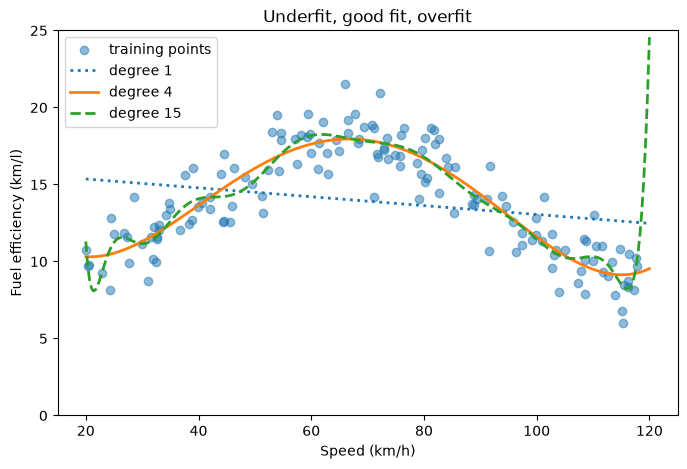

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train * 50 + 70, y_train, alpha=0.5, label='training points')

grid_x = np.linspace(-1, 1, 300).reshape(-1, 1)
for degree, style in [(1, ':'), (4, '-'), (15, '--')]:
    model, poly, _, _ = fit_polynomial(degree)
    preds = model.predict(poly.transform(grid_x))
    plt.plot(grid_x * 50 + 70, preds, style, linewidth=2, label=f'degree {degree}')

plt.ylim(0, 25)
plt.xlabel('Speed (km/h)')
plt.ylabel('Fuel efficiency (km/l)')
plt.title('Underfit, good fit, overfit')
plt.legend()
plt.show()

> **Note:** The shapes tell the same story as the numbers. The degree-1 line cuts straight through the arch and misses it everywhere. Degree 4 draws a smooth arch very close to the true dashed curve from Step 1. Degree 15 snakes from training point to training point and shoots off wildly near the edges of the data (the plot limits clip it). It has not learned the pattern; it has memorized these particular 35 points, noise included.

---
## Step 4: The Validation Curve

Three degrees gave us three snapshots. To choose the degree properly, sweep the whole range: fit every degree from 1 to 15 and plot training RMSE and validation RMSE against it.

A graph of how the training and validation scores change as a single **hyperparameter** varies is called a **validation curve**. (A hyperparameter is a setting you choose before training, like the degree here, as opposed to the weights the model learns itself.) Most hyperparameters worth sweeping control model complexity in one way or another, which is why validation curves so often have the shape you are about to see. Reading them is a core practical skill.

Lowest validation RMSE: degree 8 (1.39)


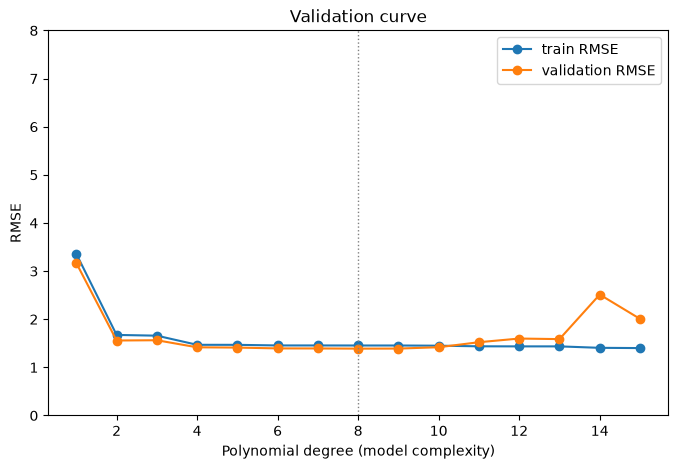

In [30]:
degrees = list(range(1, 16))
train_scores, val_scores = [], []
for degree in degrees:
    _, _, train_rmse, val_rmse = fit_polynomial(degree)
    train_scores.append(train_rmse)
    val_scores.append(val_rmse)

# np.argmin returns the INDEX of the smallest value (np.argmax: of the largest) --
# widely used whenever you need "which one won", not the winning value itself
best_degree = degrees[np.argmin(val_scores)]
print(f"Lowest validation RMSE: degree {best_degree} ({min(val_scores):.2f})")

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_scores, 'o-', label='train RMSE')
plt.plot(degrees, val_scores, 'o-', label='validation RMSE')
plt.axvline(best_degree, color='gray', linestyle=':', linewidth=1)
plt.ylim(0, 8)
plt.xlabel('Polynomial degree (model complexity)')
plt.ylabel('RMSE')
plt.title('Validation curve')
plt.legend()
plt.show()

> **Note:** The curve has three regions. On the left, both errors are high: underfitting. In the middle, validation RMSE bottoms out around 1.9 for degrees 4 to 7: the sweet spot. On the right, training RMSE keeps creeping down while validation RMSE climbs away from it: overfitting, and the gap keeps widening. Degrees 14 and 15 leave the chart entirely (validation RMSE 5.5 and 16.2).
>
> Two lessons worth remembering. Training error improves with every extra bit of complexity, always, so it can never be the basis for choosing complexity. And the exact winning degree (5 here) matters less than the region: with a different random split, degree 4 or 6 could easily win instead. Pick from the flat, stable part of the valley rather than obsessing over one point.

---
## Step 5: Regularization Instead of Manual Pruning

One fix for the degree-15 disaster is going back to degree 4: removing complexity by hand.

**Regularization** offers a different deal: keep all 15 features, but penalize large weights during training so the model cannot use its full flexibility to chase noise.

**Ridge** is linear regression with exactly this idea built in: an L2 penalty that grows with the squared size of the weights, so training must balance fitting the points against keeping the weights small. Simplifying, it looks like this: `total loss = training error + alpha * (sum of squared weights)`, where `alpha` sets how hard the weights are squeezed.

degree-15 LinearRegression:  largest |weight| = 23,970
degree-15 Ridge(alpha=0.01): largest |weight| = 19.6

model                          train RMSE  val RMSE
LinearRegression, degree 15          1.40      2.01
Ridge(alpha=0.01), degree 15         1.46      1.40


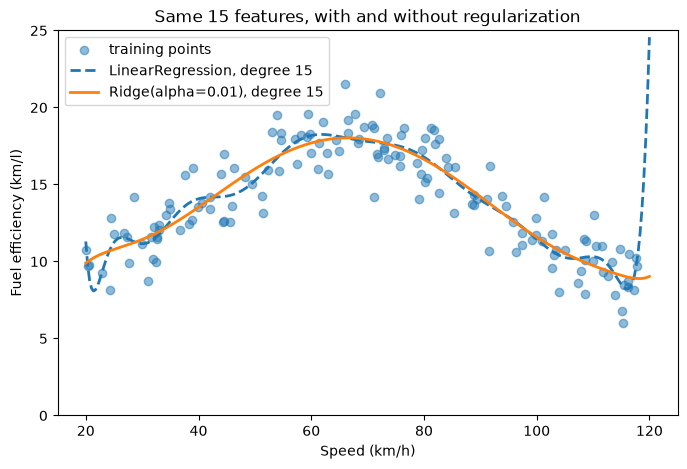

In [31]:
lin15, _, lin_train, lin_val = fit_polynomial(15)
ridge15, _, ridge_train, ridge_val = fit_polynomial(15, Ridge(alpha=0.01))

print(f"degree-15 LinearRegression:  largest |weight| = {np.abs(lin15.coef_).max():,.0f}")
print(f"degree-15 Ridge(alpha=0.01): largest |weight| = {np.abs(ridge15.coef_).max():.1f}")
print()
print(f"{'model':<30} {'train RMSE':>10} {'val RMSE':>9}")
print(f"{'LinearRegression, degree 15':<30} {lin_train:>10.2f} {lin_val:>9.2f}")
print(f"{'Ridge(alpha=0.01), degree 15':<30} {ridge_train:>10.2f} {ridge_val:>9.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_train * 50 + 70, y_train, alpha=0.5, label='training points')
poly15 = PolynomialFeatures(degree=15, include_bias=False).fit(X_train)
grid_poly = poly15.transform(grid_x)
plt.plot(grid_x * 50 + 70, lin15.predict(grid_poly), '--', linewidth=2, label='LinearRegression, degree 15')
plt.plot(grid_x * 50 + 70, ridge15.predict(grid_poly), '-', linewidth=2, label='Ridge(alpha=0.01), degree 15')
plt.ylim(0, 25)
plt.xlabel('Speed (km/h)')
plt.ylabel('Fuel efficiency (km/l)')
plt.title('Same 15 features, with and without regularization')
plt.legend()
plt.show()

> **Note:** The unregularized degree-15 model needs weights up to about 93,000 to thread through every training point. Ridge caps that appetite: its largest weight is about 12, the wiggle is gone, and validation RMSE drops from 16.22 to 1.93, essentially matching the best hand-picked degree without touching the feature set.
>
> The strength of the pull is set by `alpha`: larger alpha means stronger shrinking toward zero, and alpha that is too large would underfit, just like a degree that is too low. In other words, alpha is a complexity dial too, and you choose it exactly the way you chose the degree: sweep several values and pick the one with the best validation score.

---
## YOUR TURN

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

<b>Exercise: The sweet spot moves</b>

The right complexity is not a property of the algorithm alone. It depends on the data you have. Test that directly:

1. Set <code>noise_sd = 3.0</code> in Step 1 (keep <code>n_samples = 70</code>) and rerun the whole notebook. Record the best degree, its validation RMSE, and the validation RMSE at degree 15.

2. Set <code>noise_sd</code> back to <code>1.5</code>, change <code>n_samples</code> to <code>300</code>, and rerun. Record the same three numbers.

3. In two or three sentences: what did more noise change, what did more data change, and what does that tell you about choosing model complexity?

</div>

In [ ]:
# YOUR TURN
# 1. noise_sd = 3.0, n_samples = 70 — rerun all cells above, then record:
#    - best degree and its validation RMSE # Best degree is 5, validation RMSE is 3.8
#    - validation RMSE at degree 15 # Validation RMSE at degree 15 is 32
# 2. noise_sd = 1.5, n_samples = 300 — rerun and record the same numbers.
# 3. Your conclusions (write them here as comments, or in a new markdown cell):
#    - What did more noise change? # More noise means the model has to work harder to fit the data, so the validation RMSE is higher.
#    - What did more data change? # More data means the model has more points to fit, so the validation RMSE is lower.
#    - What does that tell you about choosing model complexity? # The best model depends on the data you have. If your data is noisy, more complex models make more mistakes. If you have more data, complex models can work better. This means there is no one perfect model, and you need to check again when your data changes.

<details><summary><b>Click for Solution</b></summary>

With `noise_sd = 3.0` (same 70 points), the curve keeps its U shape and the best degree stays around 5, but everything shifts upward: the best validation RMSE is now about 3.8 instead of 1.9, and degree 15 blows up to a validation RMSE around 32. No model, at any degree, gets close to the old scores. That floor is the noise itself: error that comes from randomness in the data cannot be modeled away, and more noise raises the floor for every model.

With `n_samples = 300` (noise back to 1.5), the right side of the curve flattens dramatically. The best degree drifts up to around 8 (validation RMSE about 1.4), and degree 15 now scores about 2.0, only modestly worse than the best, instead of roughly eight times worse. With more data, the flexible model has too many points to memorize, so high complexity stops being dangerous.

The takeaway: the sweet spot is a property of the model *and* the data together. Noisier data punishes complexity harder; more data makes complexity safer. This is why there is no universal "right" model complexity, and why you re-check the validation curve when the dataset changes.

</details>

---
## What You Should Be Able to Do Now

- Diagnose underfitting and overfitting from a pair of train and validation scores.
- Explain why training error alone always favors the most complex model.
- Build a validation curve by sweeping a complexity setting, and read its three regions.
- Point to the train-validation gap, not either number alone, as the signature of overfitting.
- Explain in one or two sentences how regularization controls complexity without removing features.